In [ ]:
""" BLOCK 1 - MANUALLY CLASSIFY ICE VS WATER IMAGES """
import os
import shutil
from pathlib import Path
from datetime import datetime

# set base path here, build folder structure
base_dir = Path(r"E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\YF")
rgb_dir = base_dir / "RGB_JPEGs"
for folder in ["_WATER", "_ICE"]:
    (base_dir / folder).mkdir(exist_ok=True)
breakup_dir = rgb_dir / "Breakup"
freezeup_dir = rgb_dir / "Freezeup"

breakup_dir.mkdir(exist_ok=True)
freezeup_dir.mkdir(exist_ok=True)

# threshold for sorting 
threshold_date = datetime.strptime("0815", "%m%d").timetuple().tm_yday  # August 15 as day of year cutoff to split into freezeup vs breakup

# iterate through all JPG files and classify 
for img_path in rgb_dir.glob("*.jpg"):
    # Example filename: S2A_6WWU_20190428_1_L2A_RGB.jpg
    # Extract date pattern (8 digits)
    parts = img_path.stem.split('_')
    date_strs = [p for p in parts if len(p) == 8 and p.isdigit()]
    if not date_strs:
        print(f"Could not find date in {img_path.name}, skipping.")
        continue

    date_str = date_strs[0]
    year = int(date_str[:4])
    month = int(date_str[4:6])
    day = int(date_str[6:8])

    file_date = datetime(year, month, day)
    day_of_year = file_date.timetuple().tm_yday

    if day_of_year < threshold_date:
        dest_folder = breakup_dir
    else:
        dest_folder = freezeup_dir

    # Move file
    dest_path = dest_folder / img_path.name
    shutil.move(str(img_path), dest_path)
    print(f"Moved {img_path.name} to {dest_folder.name}")

print("Sorting complete.")
print("Folders _WATER and _ICE created in base study site folder.")

In [3]:
""" BLOCK 2 - SAMPLE PIXELS FROM EACH CLASSIFIED LAKE INTO PARQUET FILE """

import os
import glob
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import box, mapping
from tqdm import tqdm
import pyarrow.parquet as pq
import pyarrow as pa
from numba import njit
from pyproj import CRS as ProjCRS

# Numba helpers
SCL_INVALID_CODES = np.array([0, 1, 2, 3, 7, 8, 9, 10], dtype=np.uint8)

@njit(parallel=True, fastmath=True)
def valid_mask_from_scl_numba(scl, nodata_val, invalid_codes):
    mask = np.ones(scl.shape, dtype=np.bool_)
    for i in range(scl.shape[0]):
        for j in range(scl.shape[1]):
            val = scl[i, j]
            if val == nodata_val:
                mask[i, j] = False
                continue
            for code in invalid_codes:
                if val == code:
                    mask[i, j] = False
                    break
    return mask


def sample_valid_pixels(valid_mask, n, seed=None):
    """Fast pixel sampling using NumPy."""
    if seed is not None:
        np.random.seed(seed)
    ys, xs = np.nonzero(valid_mask)
    if len(ys) == 0:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)
    if n >= len(ys):
        return ys, xs
    idx = np.random.choice(len(ys), size=n, replace=False)
    return ys[idx], xs[idx]


def resolve_epsg_from_crs(crs):
    """
    Robustly resolve an integer EPSG code from a rasterio CRS object.
    rasterio's .to_epsg() returns None when the WKT lacks a root AUTHORITY
    tag (common in some Sentinel-2 products).  pyproj matches against its
    internal CRS database and handles those cases correctly.
    """
    if crs is None:
        return None
    try:
        epsg = ProjCRS(crs.to_wkt()).to_epsg(min_confidence=20)
        if epsg is not None:
            return epsg
    except Exception:
        pass
    # fallback to rasterio's own method
    return crs.to_epsg()


def detect_epsg_from_rasters(site_dir, candidate_epsgs=(32604, 32605, 32606)):
    """
    Reads the CRS from the first .tif found under site_dir and picks the
    closest matching EPSG from candidate_epsgs.  Falls back to the first
    candidate if no raster is found.

    Uses pyproj for EPSG resolution so that WKTs without a root AUTHORITY
    tag (e.g. many Sentinel-2 GeoTIFFs) are handled correctly.
    """
    tif_files = glob.glob(os.path.join(site_dir, "**", "*.tif"), recursive=True)
    if not tif_files:
        print(f"[EPSG detect] No .tif files found under {site_dir}. "
              f"Defaulting to EPSG:{candidate_epsgs[0]}")
        return candidate_epsgs[0]

    with rasterio.open(tif_files[0]) as src:
        raster_epsg = resolve_epsg_from_crs(src.crs)

    print(f"[EPSG detect] First raster : {tif_files[0]}")
    print(f"[EPSG detect] Resolved EPSG: {raster_epsg}")

    if raster_epsg in candidate_epsgs:
        print(f"[EPSG detect] Matched candidate -> using EPSG:{raster_epsg}")
        return raster_epsg

    # Pick whichever candidate is numerically closest
    best = min(
        candidate_epsgs,
        key=lambda e: abs(e - raster_epsg) if raster_epsg is not None else 0
    )
    print(f"[EPSG detect] EPSG:{raster_epsg} not in candidates {candidate_epsgs}. "
          f"Using closest candidate: EPSG:{best}")
    return best


def run_diagnostics(site_dir, class_folders, gdf_lakes, sentinel_epsg):
    """
    Prints a detailed diagnostic report for the first scene found so you can
    identify exactly which stage of the pipeline is failing before the main
    loop runs.
    """
    print("\n" + "="*60)
    print("DIAGNOSTIC REPORT")
    print("="*60)

    # --- 1. Class folders & jpg counts ---
    print("\n[1] Class folders")
    records = []
    for label, fdir in class_folders.items():
        exists = os.path.exists(fdir)
        jpgs = glob.glob(os.path.join(fdir, "*.jpg")) if exists else []
        print(f"  {label}: exists={exists}, jpg count={len(jpgs)}")
        for jpg_path in jpgs:
            records.append({"scene_name": os.path.basename(jpg_path), "class": label})

    df_class = pd.DataFrame(records)
    print(f"  Total scenes in df_class: {len(df_class)}")
    if df_class.empty:
        print("  !! df_class is EMPTY - no .jpg files found. Check folder paths / names.")
        print("="*60 + "\n")
        return df_class

    # --- 2. Lake shapefile ---
    print(f"\n[2] Lake shapefile")
    print(f"  Lake count      : {len(gdf_lakes)}")
    print(f"  Lakes CRS       : {gdf_lakes.crs}")
    print(f"  Using EPSG      : {sentinel_epsg}")
    print(f"  Lakes bounds    : {gdf_lakes.total_bounds}")

    # --- 3. First scene deep-dive ---
    print(f"\n[3] First scene deep-dive")
    rec = df_class.iloc[0]
    scene_name   = rec["scene_name"]
    scene_token  = scene_name.split("_RGB")[0]
    scene_folder = os.path.join(site_dir, scene_token)

    print(f"  scene_name      : {scene_name}")
    print(f"  scene_token     : {scene_token}")
    print(f"  scene_folder    : {scene_folder}")
    print(f"  folder exists   : {os.path.exists(scene_folder)}")

    if not os.path.exists(scene_folder):
        subdirs = [d for d in os.listdir(site_dir)
                   if os.path.isdir(os.path.join(site_dir, d))][:10]
        print(f"  !! Folder not found. First 10 subdirs in site_dir: {subdirs}")
        print("="*60 + "\n")
        return df_class

    desired_bands = ["B02", "B03", "B04", "B08", "B11", "B12"]
    band_paths    = [os.path.join(scene_folder, f"{b}.tif") for b in desired_bands]
    found_bands   = [p for p in band_paths if os.path.exists(p)]
    missing_bands = [p for p in band_paths if not os.path.exists(p)]
    print(f"  Bands found     : {[os.path.basename(p) for p in found_bands]}")
    print(f"  Bands missing   : {[os.path.basename(p) for p in missing_bands]}")

    scl_path = os.path.join(scene_folder, "SCL.tif")
    print(f"  SCL.tif exists  : {os.path.exists(scl_path)}")

    if not found_bands:
        print("  !! No band .tif files found in scene folder.")
        print("="*60 + "\n")
        return df_class

    # --- 4. CRS / bounds overlap check ---
    print(f"\n[4] CRS & spatial overlap check")
    ref_path = found_bands[0]
    with rasterio.open(ref_path) as src:
        r_crs    = src.crs
        r_epsg   = resolve_epsg_from_crs(src.crs)
        r_bounds = rasterio.transform.array_bounds(src.height, src.width, src.transform)
        print(f"  Raster CRS      : {r_crs}")
        print(f"  Raster EPSG     : {r_epsg}")
        print(f"  Raster bounds   : {r_bounds}")

    raster_box    = box(*r_bounds)
    lakes_in_scene = gdf_lakes[gdf_lakes.intersects(raster_box)]
    print(f"  Lakes intersecting scene: {len(lakes_in_scene)}")
    if lakes_in_scene.empty:
        print("  !! No lakes intersect this scene.")
        print("     Possible causes: wrong EPSG, lakes outside raster extent, CRS mismatch.")
        print(f"  Lake bounds  : {gdf_lakes.total_bounds}")
        print(f"  Raster bounds: {r_bounds}")
    else:
        print(f"  OK - lakes found. First lake geometry type: "
              f"{lakes_in_scene.geometry.iloc[0].geom_type}")

    # --- 5. SCL valid pixel check ---
    if os.path.exists(scl_path) and found_bands:
        print(f"\n[5] SCL valid pixel check")
        with rasterio.open(ref_path) as ref_src:
            h, w      = ref_src.height, ref_src.width
            transform = ref_src.transform
        with rasterio.open(scl_path) as srcs:
            scl = srcs.read(1, out_shape=(h, w),
                            resampling=rasterio.enums.Resampling.nearest)
            nodata_val = srcs.nodata if srcs.nodata is not None else 0
        valid_mask = valid_mask_from_scl_numba(
            scl.astype(np.uint8), np.uint8(nodata_val), SCL_INVALID_CODES)
        n_valid = int(valid_mask.sum())
        n_total = valid_mask.size
        print(f"  Valid pixels    : {n_valid:,} / {n_total:,} "
              f"({100*n_valid/n_total:.1f}%)")
        if n_valid == 0:
            print("  !! ALL pixels are masked by SCL. Scene will be skipped.")

    print("\n" + "="*60 + "\n")
    return df_class


def generate_training_parquet(
    base_dir,
    study_site,
    lake_shp,
    out_training_path,
    num_samples_per_lake=5,
    sentinel_epsg=None,           # if None, auto-detected from rasters
    candidate_epsgs=(32604, 32605, 32606),
):
    """Generate Sentinel-2 training samples with SCL values."""

    site_dir = os.path.join(base_dir, study_site)
    class_folders = {
        "ice":   os.path.join(site_dir, "FREEZEUP_ICE"),
        "water": os.path.join(site_dir, "FREEZEUP_WATER"),
    }

    # --- Auto-detect EPSG if not provided ---
    if sentinel_epsg is None:
        sentinel_epsg = detect_epsg_from_rasters(site_dir, candidate_epsgs)
    else:
        print(f"[EPSG] Using user-supplied EPSG:{sentinel_epsg}")

    # --- Load lakes reprojected to the detected raster CRS ---
    gdf_lakes = gpd.read_file(lake_shp).to_crs(epsg=sentinel_epsg)

    # --- Run diagnostics before the main loop ---
    df_class = run_diagnostics(site_dir, class_folders, gdf_lakes, sentinel_epsg)

    if df_class.empty:
        raise RuntimeError(
            "Diagnostics found no scenes to process. "
            "Fix the issues printed above, then re-run."
        )

    all_samples  = []
    skip_reasons = {
        "no_scene_folder": 0,
        "no_bands":        0,
        "no_lakes":        0,
        "no_valid_pixels": 0,
    }

    for i, rec in tqdm(df_class.iterrows(), total=len(df_class), desc="Processing scenes"):
        scene_name   = rec["scene_name"]
        label        = rec["class"]

        scene_token  = scene_name.split("_RGB")[0]
        scene_folder = os.path.join(site_dir, scene_token)

        if not os.path.exists(scene_folder):
            skip_reasons["no_scene_folder"] += 1
            continue

        desired_bands = ["B02", "B03", "B04", "B08", "B11", "B12"]
        band_paths = [
            os.path.join(scene_folder, f"{b}.tif")
            for b in desired_bands
            if os.path.exists(os.path.join(scene_folder, f"{b}.tif"))
        ]

        if not band_paths:
            skip_reasons["no_bands"] += 1
            continue

        scl_path = os.path.join(scene_folder, "SCL.tif")

        # Use a 10 m band as spatial reference
        prefer_10m    = [p for p in band_paths if any(b in p for b in ["B02", "B03", "B04", "B08"])]
        ref_band_path = prefer_10m[0] if prefer_10m else band_paths[0]

        with rasterio.open(ref_band_path) as ref_src:
            height, width = ref_src.height, ref_src.width
            transform     = ref_src.transform

        # Load all bands resampled to reference resolution
        band_stack, band_names = [], []
        for bp in band_paths:
            bname = os.path.basename(bp)
            with rasterio.open(bp) as src:
                data = src.read(
                    1, out_shape=(height, width),
                    resampling=rasterio.enums.Resampling.nearest
                )
            band_stack.append(data)
            band_names.append(os.path.splitext(bname)[0])
        band_stack = np.stack(band_stack)

        # Load SCL mask
        with rasterio.open(scl_path) as srcs:
            scl = srcs.read(
                1, out_shape=(height, width),
                resampling=rasterio.enums.Resampling.nearest
            )
            nodata_val = srcs.nodata if srcs.nodata is not None else 0

        valid_mask = valid_mask_from_scl_numba(
            scl.astype(np.uint8), np.uint8(nodata_val), SCL_INVALID_CODES
        )

        # Spatial filter: keep only lakes that overlap this scene
        raster_bounds  = box(*rasterio.transform.array_bounds(height, width, transform))
        lakes_in_scene = gdf_lakes[gdf_lakes.intersects(raster_bounds)]
        if lakes_in_scene.empty:
            skip_reasons["no_lakes"] += 1
            continue

        geoms = [
            mapping(l.geometry.intersection(raster_bounds))
            for _, l in lakes_in_scene.iterrows()
            if not l.geometry.is_empty
        ]
        if not geoms:
            skip_reasons["no_lakes"] += 1
            continue

        lake_mask     = ~geometry_mask(geoms, transform=transform, invert=True,
                                       out_shape=(height, width))
        combined_mask = valid_mask & lake_mask
        total_samples = num_samples_per_lake * len(geoms)
        ys, xs        = sample_valid_pixels(combined_mask, total_samples, seed=42)

        if len(ys) == 0:
            skip_reasons["no_valid_pixels"] += 1
            continue

        # Build per-pixel records
        sample_records = []
        for y, x in zip(ys, xs):
            sample_data = {name: float(band_stack[k, y, x])
                           for k, name in enumerate(band_names)}
            sample_data["SCL"] = int(scl[y, x])
            sample_data.update({
                "scene": scene_token,
                "label": label,
                "row":   int(y),
                "col":   int(x),
            })
            sample_records.append(sample_data)

        if sample_records:
            all_samples.append(pd.DataFrame(sample_records))

    # --- Skip-reason summary ---
    print("\n[Skip summary]")
    for reason, count in skip_reasons.items():
        print(f"  {reason}: {count} scene(s) skipped")
    print(f"  Scenes with samples: {len(all_samples)}")

    if not all_samples:
        raise RuntimeError(
            "No samples collected after processing all scenes.\n"
            "Review the skip summary and diagnostic report above.\n"
            "Most likely causes:\n"
            "  1. scene_token parse mismatch (check _RGB split logic)\n"
            "  2. Wrong EPSG - lakes don't overlap rasters\n"
            "  3. All pixels masked out by SCL"
        )

    # --- Save ---
    df_all = pd.concat(all_samples, ignore_index=True)
    print(f"\nSaving {len(df_all):,} samples to:\n  {out_training_path}")

    table = pa.Table.from_pandas(df_all)
    os.makedirs(os.path.dirname(out_training_path), exist_ok=True)
    pq.write_table(table, out_training_path)
    print("Done.")


# =============================================================================
# RUN
# =============================================================================
output_path = (
    r"E:\planetscope_lake_ice\Data\Input"
    r"\Machine Learning - Sentinel Samples for RF"
    r"\Models\NS Freezeup\NS_freezeup.parquet"
)

generate_training_parquet(
    base_dir    = r"E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF",
    study_site  = "NS",
    lake_shp    = (
        r"E:\planetscope_lake_ice\Data\Input\Study Sites - Manual ALPOD Data"
        r"\NS 50x50 km\NS Lakes from ALPOD Shapefile\NS_50x50km_lakes.shp"
    ),
    out_training_path    = output_path,
    num_samples_per_lake = 5,
    sentinel_epsg        = None,                  # auto-detected from rasters
    candidate_epsgs      = (32604, 32605, 32606),  # zone 4N added
)

[EPSG detect] First raster : E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\NS\S2A_4WFD_20190519_0_L2A\B01.tif
[EPSG detect] Resolved EPSG: 32604
[EPSG detect] Matched candidate -> using EPSG:32604

DIAGNOSTIC REPORT

[1] Class folders
  ice: exists=True, jpg count=15
  water: exists=True, jpg count=9
  Total scenes in df_class: 24

[2] Lake shapefile
  Lake count      : 5694
  Lakes CRS       : EPSG:32604
  Using EPSG      : 32604
  Lakes bounds    : [ 613669.89740223 7808421.1546218   665885.27059077 7860791.5674131 ]

[3] First scene deep-dive
  scene_name      : S2A_4WFD_20200530_0_L2A_RGB.jpg
  scene_token     : S2A_4WFD_20200530_0_L2A
  scene_folder    : E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\NS\S2A_4WFD_20200530_0_L2A
  folder exists   : True
  Bands found     : ['B02.tif', 'B03.tif', 'B04.tif', 'B08.tif', 'B11.tif', 'B12.tif']
  Bands missing   : []
  SCL.tif exists  : True

[4] CRS & spatial overlap check
  

Processing scenes: 100%|██████████| 24/24 [04:07<00:00, 10.30s/it]



[Skip summary]
  no_scene_folder: 0 scene(s) skipped
  no_bands: 0 scene(s) skipped
  no_lakes: 10 scene(s) skipped
  no_valid_pixels: 0 scene(s) skipped
  Scenes with samples: 14

Saving 398,580 samples to:
  E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\Models\NS Freezeup\NS_freezeup.parquet
Done.



Classes: ['ice', 'water'] -> [0, 1]

Splitting data: 80% train, 20% test...
Training samples: 318864
Test samples: 79716
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_split: 2
  n_estimators: 500
Best CV accuracy: 0.9866181197853372
Best model CV train accuracy: 1.0
Best model CV val accuracy: 0.9866181197853372
Classification Report (Test):
              precision    recall  f1-score   support

         ice       0.99      0.99      0.99     56940
       water       0.98      0.98      0.98     22776

    accuracy                           0.99     79716
   macro avg       0.98      0.98      0.98     79716
weighted avg       0.99      0.99      0.99     79716



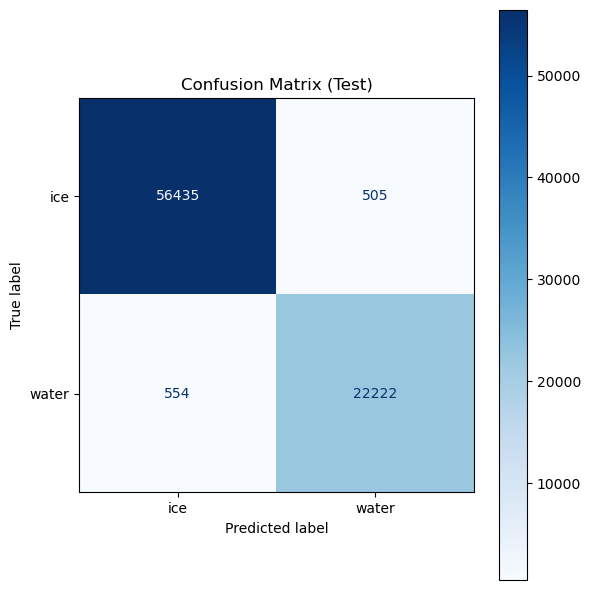

Final model trained
Feature importances:
1. B04       : 0.24525472936333242
2. B02       : 0.22734080028257764
3. B03       : 0.1646603442041878
4. SCL       : 0.14618421323396832
5. B08       : 0.09592264001895799
6. B11       : 0.06527331564978961
7. B12       : 0.05536395724718622

Feature importance plot saved


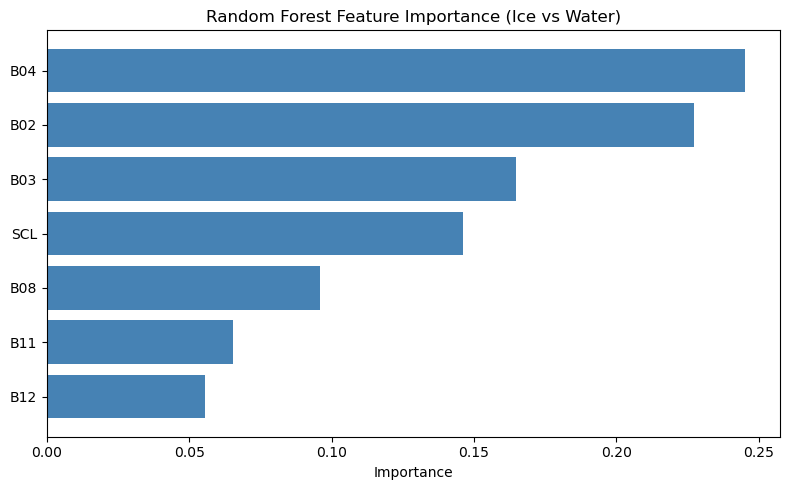

Feature importances exported to: E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\Models\NS Freezeup\NS_freezeup_feature_importance.csv
model package saved to: E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\Models\NS Freezeup\NS_freezeup_RFmodel.joblib


In [5]:
""" BLOCK 3 - RANDOM FOREST W/ CV HYPERPARAMETER TUNING """
import pandas as pd
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt

# input filepaths -> CHANGE PQT
base_dir = r"E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF"
parquet_path = os.path.join(r"E:\planetscope_lake_ice\Data\Input\Machine Learning - Sentinel Samples for RF\Models\NS Freezeup\NS_freezeup.parquet") #pqt output path
model_out_path = parquet_path.replace(".parquet", "_RFmodel.joblib")
test_size = 0.2  # hold out 20% for final testing
random_state = 42

# load data
df = pq.read_table(parquet_path).to_pandas()

# drop non-feature columns to exclude from RF
feature_cols = [c for c in df.columns if c not in {"scene", "label", "row", "col"}]
X = df[feature_cols].astype(float)

# encode text labels ("ice"/"water")
le = LabelEncoder()
y = le.fit_transform(df["label"])
print(f"\nClasses: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

# train/test split 
print(f"\nSplitting data: {100*(1-test_size):.0f}% train, {100*test_size:.0f}% test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# run model
rf = RandomForestClassifier(random_state=random_state, n_jobs=-1)

param_grid = {
    "n_estimators": [300,400,500],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# fit model with cross validation on training set
grid_search.fit(X_train, y_train)

print("Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV accuracy: {grid_search.best_score_}")

# check for overfitting in CV
cv_results = pd.DataFrame(grid_search.cv_results_)
best_idx = grid_search.best_index_
train_score = cv_results.loc[best_idx, 'mean_train_score']
val_score = cv_results.loc[best_idx, 'mean_test_score']
print(f"Best model CV train accuracy: {train_score}")
print(f"Best model CV val accuracy: {val_score}")

# evaluate on test set, print results
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)

print("Classification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')

plt.title('Confusion Matrix (Test)')
plt.tight_layout()
plt.savefig(model_out_path.replace("_RFmodel.joblib", "_confusion_matrix.png"), dpi=150)
plt.show()

# train final model on all data
final_model = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=random_state,
    n_jobs=-1
)
final_model.fit(X, y)
print("Final model trained")

#  feature importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]

print("Feature importances:")
for rank, (feat, imp) in enumerate(zip(sorted_features, importances[indices]), 1):
    print(f"{rank}. {feat:10s}: {imp}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sorted_features[::-1], importances[indices][::-1], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance (Ice vs Water)")
plt.tight_layout()
plt.savefig(model_out_path.replace("_RFmodel.joblib", "_feature_importance.png"), dpi=150)
print(f"\nFeature importance plot saved")
plt.show()

# save to CSV
fi_df = pd.DataFrame({
    "band": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)
fi_csv = model_out_path.replace("_RFmodel.joblib", "_feature_importance.csv")
fi_df.to_csv(fi_csv, index=False)
print(f"Feature importances exported to: {fi_csv}")

# save trained model
model_package = {
    "model": final_model,
    "label_encoder": le,
    "feature_columns": feature_cols,
    "best_params": grid_search.best_params_,
    "cv_score": grid_search.best_score_,
    "test_accuracy": (y_pred_test == y_test).mean(),
    "training_samples": len(df)
}

joblib.dump(model_package, model_out_path)
print(f"model package saved to: {model_out_path}")